In [1]:
import pandas as pd
import numpy as np
import os
import torch
import seaborn as sns
import random
import pickle
import matplotlib.gridspec as gridspec


from scipy.stats import pearsonr, spearmanr
from scipy.stats import rankdata
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc


from Bio import pairwise2
from Bio.Seq import Seq
from Bio.Align import substitution_matrices
from Bio import SeqIO

from random import sample

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    positions,
    num_muts_column_name,
    DATASET_PATHS
)


/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
across_datasets_results = {}

In [3]:

def get_relevant_columns_gfp_protgym(df, first_col, last_col):
    si = np.where(df.columns == first_col)[0][0]
    ei = np.where(df.columns == last_col)[0][0]+1
    return df.columns[si:ei]

def nmt_relevant_columns(df):
    si = np.where(df.columns == "1")[0][0]
    ei = np.where(df.columns == "272")[0][0]+1
    positions_with_mutations =  np.array([len(pd.unique(df.iloc[:,i])) > 1 for i in range(si,ei)])
    return df.columns[si:ei][positions_with_mutations]

def get_relevant_columns(dataset, df):
    cols = get_relevant_columns_gfp_protgym(df, positions[dataset][0], positions[dataset][1])
    return cols



# --- OHE Feature Creation ---
def get_one_hot_encoding(sdf, relevant_columns):
    one_hot_encoding = pd.get_dummies(sdf[relevant_columns])
    return one_hot_encoding

datasets_and_activity = {
    "gcn4": {"path": "./data/gcn4/gcn4.csv", "activity_col": "activity"},
    "pard3": {"path": "./data/pard3/pard3.csv", "activity_col": "activity"},
    "pte": {"path": "./data/pte/pte.csv", "activity_col": "p-nitrophenyl_octanoate"},
    "nmt": {"path": "./data/nmt/nmt_full_seq.csv", "activity_col": "activity"},
    "lov": {"path": "./data/lov/lov.csv", "activity_col": "activity"},
    "gfp": {"path": "./data/gfp/gfp_dataset_10mut.csv", "activity_col": "inactive"},
    "aamyl": {"path": "./data/aamyl/aamyl.csv", "activity_col": "activity"},
    "trpb": {"path": "./data/trpb/trpb.csv", "activity_col": "activity"},
    "his": {"path": "./data/his/his.csv", "activity_col": "activity"},
    "casp": {"path": "./data/casp/casp.csv", "activity_col": "activity"}
}

names_dict = {
    "esm2_t6_8M_UR50D": "ESM2 (8m)", 
    "esm2_t12_35M_UR50D": "ESM2 (35m)", 
    "esm2_t30_150M_UR50D": "ESM2 (150m)", 
    "esm2_t33_650M_UR50D" : "ESM2 (650m)",
    "pssm": "PSSM"
}



def get_best_worst_ranks(best, worst):
    """
    Given arrays or lists of best and worst scores,
    returns (ranks_best, ranks_worst) where each contains
    the rank (1 = highest) of each input element.
    """
    all_scores = np.array(list(best) + list(worst))
    # Higher score = higher rank, so negate for ranking function
    ranks = rankdata(-all_scores, method='average')
    ranks_best = ranks[:len(best)]
    ranks_worst = ranks[len(best):]
    return ranks_best, ranks_worst


import sys
os.chdir(os.path.join(os.getcwd(), "../code/"))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from plm_base import *
plm_init(os.path.join(os.getcwd(), "../"))

os.chdir(os.path.join(os.getcwd(), "../notebooks"))



/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def get_one_hot_encoding(sdf, relevant_columns):
    one_hot_encoding = pd.get_dummies(sdf[relevant_columns])
    return one_hot_encoding

In [5]:

# Define desired dataset order
dataset_order = ["his", "casp", "trpb", "aamyl", "gfp","pard3", "pte", "gcn4", "nmt", "lov"]

sample_settings = {

    "gcn4": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5,10,20,50,100]
    },
    "pard3": {
        "space_sizes": [3,4,5,6,7,8,9,10,20],
        "k_values": [5,10,20,50,100],
    },
    "aamyl": {
        "space_sizes": [3,4,5,6,7,8,9,10,20],
        "k_values": [5,10,20,50,100]
    },
    "gfp": {
        "space_sizes": [3,4,5,6,7,8],
        "k_values": [5, 10, 50, 100, 200]
    },
    "his": {
        "space_sizes": [3,4,5,6,7,8],
        "k_values": [5, 10, 50, 100, 200]
    },
    "casp": {
        "space_sizes": [3,4,5,6,7,8],
        "k_values": [5, 10, 50, 100, 200]
    },    
    "trpb": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5, 10, 50, 100, 200]
    },
    "lov": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5, 10, 50, 100, 200, 500]
    },
    "nmt": {
        "space_sizes": [3,4,5,6,7,8,9,10,20,25],
        "k_values": [4, 5, 8, 10, 15, 20, 30, 40, 50]
    },
    "pte": {
        "space_sizes": [2,3,4],
        "k_values": [4, 5, 8, 10, 15, 20]
    }
}

In [6]:

def calc_pssm_matrices(
    pssm_score_per_mutation,
    actual_pos_per_ohe_col,
    activity,
    ohe,
    space_sizes,
    k_values,
    percentile=90,
    unique_mutations=False,
):
    # Rank mutations by PSSM score (descending)
    pssm_rank = np.argsort(-pssm_score_per_mutation)

    gof_threshold = np.percentile(activity, 90)
    #gof_threshold = 1
    gof_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=int)
    mean_activity_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)
    median_activity_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)
    chosen_indices = {}

    for s_idx, s in enumerate(space_sizes):
        # Find indices of top N+1 unique mutations by PSSM score

        if unique_mutations:
            pssm_first_unique_indices = []
            seen = set()
            arr = np.array(actual_pos_per_ohe_col)[pssm_rank]
            for idx, val in enumerate(arr):
                if val not in seen:
                    pssm_first_unique_indices.append(idx)
                    seen.add(val)
                if len(pssm_first_unique_indices) == s:
                    break
            chosen_mutations_pssm = pssm_rank[pssm_first_unique_indices]            
        else:
            chosen_mutations_pssm = pssm_rank[:s]

        chosen_indices[s] = chosen_mutations_pssm

        # Select N unique mutation columns, score each sequence by sum of their OHE columns
        closest_to_pssm_space = np.argsort(
            -ohe[:, chosen_mutations_pssm].sum(axis=1)
        )

        # For each top-K
        for k_idx, k in enumerate(k_values):
            activities_pssm = activity[closest_to_pssm_space[:k]]
            # Number of GOF (above upper 90th percentile)
            num_of_gof = np.sum(activities_pssm > gof_threshold)
            # Mean activity
            mean_activity = np.mean(activities_pssm)
            median_activity = np.median(activities_pssm)

            gof_matrix[s_idx, k_idx] = num_of_gof
            mean_activity_matrix[s_idx, k_idx] = mean_activity
            median_activity_matrix[s_idx, k_idx] = median_activity

    return gof_matrix, mean_activity_matrix, median_activity_matrix, chosen_indices

def get_top_worst_K_mutations_empirical(
    ohe,
    activity,
    K=5,
    plot=False
):
    mean_with_mutation_per_column = []
    mean_without_mutation_per_column = []
    for i in range(ohe.shape[1]):
        mean_val_with_mutation = np.mean(activity[np.where(ohe[:, i] == 1)[0]])
        mean_val_without_mutation = np.mean(activity[np.where(ohe[:, i] == 0)[0]])
        mean_with_mutation_per_column.append(mean_val_with_mutation/mean_val_without_mutation)
        mean_without_mutation_per_column.append(mean_val_without_mutation/mean_val_with_mutation)


    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(6,3))

        axes[0].scatter(mean_without_mutation_per_column, mean_with_mutation_per_column)
        axes[0].set_xlabel("Mean without mutation")
        axes[0].set_ylabel("Mean with mutation")
        axes[0].set_title("With vs Without Mutation")

        ratio = np.array(mean_with_mutation_per_column) / np.array(mean_without_mutation_per_column)
        axes[1].hist(ratio, bins=20)
        axes[1].set_xlabel("With / Without Mutation Ratio")
        axes[1].set_ylabel("Frequency")
        axes[1].set_title("Distribution of Ratio")

        plt.tight_layout()
        plt.show()

    ratio = np.array(mean_with_mutation_per_column)/np.array(mean_without_mutation_per_column)
    worst_K_indices = np.argsort(ratio)[0:K]
    best_K_indices  = np.argsort(-ratio)[0:K]

    return (best_K_indices, worst_K_indices, ratio)


def run_model(
    pssm,
    ohe,
    ohe_columns,
    activity,
    vocab_col_idx_dict,
    k_values,
    space_sizes,
    plot=False
):    

    best_K_empirical_indices, worst_K_empirical_indices, ratio = get_top_worst_K_mutations_empirical(
        ohe,
        activity,
        K=5,
        plot=plot
    )

    best_K_empirical_mutations = ohe_columns[best_K_empirical_indices]
    worst_K_empirical_mutations = ohe_columns[worst_K_empirical_indices]

    actual_pos_per_ohe_col = [int(col.split("_")[0][1:]) for col in ohe_columns] # PDB INDEX
    actual_vocab_per_ohe_col = [col.split("_")[-1] for col in ohe_columns] 
    pssm_score_per_mutation = []

    for p,v in zip(actual_pos_per_ohe_col, actual_vocab_per_ohe_col):
        col_idx = vocab_col_idx_dict[v]
        row_idx = p - 1 # IT SHOULD BE PDB IDX!!!!!!!!!!!
        pssm_score_per_mutation.append(pssm[row_idx,col_idx])

    pssm_score_per_mutation = np.array(pssm_score_per_mutation)

    pssm_scores_best = pssm_score_per_mutation[best_K_empirical_indices]
    pssm_scores_worst = pssm_score_per_mutation[worst_K_empirical_indices]

    # PSSM ranks
    ranks_best, ranks_worst = get_best_worst_ranks(
        pssm_scores_best, 
        pssm_scores_worst
    )

    unique_results = calc_pssm_matrices(
        pssm_score_per_mutation,
        actual_pos_per_ohe_col,
        activity,
        ohe,
        k_values=k_values,
        space_sizes=space_sizes,
        unique_mutations=True
    )

    unique_gof_matrix, unique_mean_activity_matrix, unique_median_activity_matrix, unique_chosen_indices = unique_results

    
    non_unique_results = calc_pssm_matrices(
        pssm_score_per_mutation,
        actual_pos_per_ohe_col,
        activity,
        ohe,
        k_values=k_values,
        space_sizes=space_sizes,
        unique_mutations=False
    )

    non_unique_gof_matrix, non_unique_mean_activity_matrix, non_unique_median_activity_matrix, non_unique_chosen_indices = non_unique_results
    empirical_vs_model_prob_spearmanr = spearmanr(ratio, pssm_score_per_mutation)

    results = {
        "empirical_vs_model_prob_spearmanr": empirical_vs_model_prob_spearmanr,
        "unique_gof_matrix": unique_gof_matrix,
        "unique_mean_activity_matrix": unique_mean_activity_matrix,
        "unique_median_activity_matrix": unique_median_activity_matrix,
        "non_unique_gof_matrix": non_unique_gof_matrix,
        "non_unique_mean_activity_matrix": non_unique_mean_activity_matrix,
        "non_unique_median_activity_matrix": non_unique_median_activity_matrix,
        "ranks_best": ranks_best,
        "ranks_worst": ranks_worst,
        "empirical_vs_model_prob_spearmanr": empirical_vs_model_prob_spearmanr,
        "unique_chosen_indices": unique_chosen_indices,
        "non_unique_chosen_indices": non_unique_chosen_indices,
    }

    return results


In [ ]:

overwrite = True
hybridize = False

if os.path.exists('all_results.pkl') and not overwrite:
    with open('all_results.pkl', 'rb') as f:
        all_results = pickle.load(f)
else:
    all_results = {}
    all_models = [
        "esm2_t6_8M_UR50D", 
        "esm2_t12_35M_UR50D", 
        "esm2_t30_150M_UR50D", 
        "esm2_t33_650M_UR50D"
    ]

    all_results = {}

    for model_name in all_models:

        model = plmEmbeddingModel(
            plm_name="%s" % model_name, 
            logits_only=True, 
            emb_only=False
        ).eval()
                
        for dataset in dataset_order:    
            dataset_path = DATASET_PATHS[dataset]
            df = pd.read_csv(dataset_path)
            wt_seq = df[df["num_muts"] == 0]["full_seq"].iloc[0]

            k_values = sample_settings[dataset]["k_values"]
            space_sizes = sample_settings[dataset]["space_sizes"]

            # get one-hot encoding for relevant columns
            relevant_columns = get_relevant_columns(dataset, df)
            ohe = get_one_hot_encoding(df, relevant_columns)
            ohe_columns = ohe.columns
            ohe = ohe.to_numpy().astype(int)
            assert ohe.shape[1] == sum([len(pd.unique(df[C])) for C in relevant_columns])

            activity_col = datasets_and_activity[dataset]["activity_col"]
            activity = df[activity_col].to_numpy()

            if dataset == "gfp":
                activity = (~activity).astype(int)

            pssm = pd.read_csv(f"./data/{dataset}//pssm_scores.csv")
            vocab_col_idx_dict = dict((v,i) for i,v in enumerate(pssm.columns[1:]))

            np_pssm = pssm.iloc[:,1:].to_numpy()

            pssm_results = run_model(
                np_pssm, 
                ohe,
                ohe_columns,
                activity,
                vocab_col_idx_dict,
                k_values,
                space_sizes,
                plot=False
            )

            pssm_results["actual_pssm"] = pssm
            pssm_results["actual_np_pssm"] = np_pssm

            res_name = "%s_%s" % (dataset, "pssm")

            if res_name not in all_results:
                all_results[res_name] = pssm_results

            vocab = model.vocab
            all_tokens = model.encode("".join(vocab))
            wt_tokens = model.encode(wt_seq)
            all_tokens = all_tokens[1:-1]

            logits_path = f"./data/{dataset}/%s_logits.np.npy" % model_name
            if os.path.exists(logits_path):
                logits = np.load(logits_path)
            else:
                logits = model(torch.tensor(wt_tokens).unsqueeze(0))
                logits = logits[0].softmax(dim=1)
                logits = logits.detach().numpy()
                np.save(logits_path, logits)

            model_logits = logits[1:-1,:] # Get rid

            rearranged_to_pssm_logits = []
            for vc in pssm.columns[1:]:
                rearranged_to_pssm_logits.append(model_logits[:,np.where(np.array(vocab) == vc)[0]])

            model_like_pssm = np.concatenate(rearranged_to_pssm_logits, axis=1) 
            assert np_pssm.shape == model_like_pssm.shape

            plm_results = run_model(
                model_like_pssm, 
                ohe,
                ohe_columns,
                activity,
                vocab_col_idx_dict,
                k_values,
                space_sizes
            )

            plm_results["actual_pssm"] = model_logits
            plm_results["actual_np_pssm"] = model_like_pssm

            res_name = "%s_%s" % (dataset, model_name)
            all_results[res_name] = plm_results

            if hybridize:
                hybrid_pssm = torch.from_numpy(np_pssm).to(torch.float32)
                hybrid_pssm = hybrid_pssm.softmax(dim=1)
                hybrid_pssm = hybrid_pssm.detach().numpy()
                hybrid_pssm = model_like_pssm * hybrid_pssm

                hybrid_results = run_model(
                    hybrid_pssm, 
                    ohe,
                    ohe_columns,
                    activity,
                    vocab_col_idx_dict,
                    k_values,
                    space_sizes
                )

                hybrid_results["actual_pssm"] = hybrid_pssm
                hybrid_results["actual_np_pssm"] = hybrid_pssm

                res_name = "%s_hybrid_pssm_%s" % (dataset, model_name)
                all_results[res_name] = hybrid_results

            print("Finsihed analyzing %s - %s" % (dataset, model_name))

    with open('all_results.pkl', 'wb') as f:
        pickle.dump(all_results, f)


Finsihed analyzing his - esm2_t6_8M_UR50D
Finsihed analyzing casp - esm2_t6_8M_UR50D
Finsihed analyzing trpb - esm2_t6_8M_UR50D
Finsihed analyzing aamyl - esm2_t6_8M_UR50D
Finsihed analyzing gfp - esm2_t6_8M_UR50D
Finsihed analyzing pard3 - esm2_t6_8M_UR50D
Finsihed analyzing pte - esm2_t6_8M_UR50D
Finsihed analyzing gcn4 - esm2_t6_8M_UR50D
Finsihed analyzing nmt - esm2_t6_8M_UR50D
Finsihed analyzing lov - esm2_t6_8M_UR50D
Finsihed analyzing his - esm2_t12_35M_UR50D
Finsihed analyzing casp - esm2_t12_35M_UR50D
Finsihed analyzing trpb - esm2_t12_35M_UR50D
Finsihed analyzing aamyl - esm2_t12_35M_UR50D
Finsihed analyzing gfp - esm2_t12_35M_UR50D
Finsihed analyzing pard3 - esm2_t12_35M_UR50D
Finsihed analyzing pte - esm2_t12_35M_UR50D
Finsihed analyzing gcn4 - esm2_t12_35M_UR50D
Finsihed analyzing nmt - esm2_t12_35M_UR50D
Finsihed analyzing lov - esm2_t12_35M_UR50D
Finsihed analyzing his - esm2_t30_150M_UR50D
Finsihed analyzing casp - esm2_t30_150M_UR50D
Finsihed analyzing trpb - esm2_t30_

In [8]:
overwrite = True
# Try to read max_scores from 'max_exploration_results.pkl' if it exists, unless overwrite is set
max_scores_path = 'new_new_max_exploration_results.pkl'
if not overwrite and os.path.exists(max_scores_path):
    with open(max_scores_path, 'rb') as f:
        max_scores = pickle.load(f)
else:
    max_scores = {}

    for dataset in dataset_order:



        if dataset in max_scores:
            print("Skipping %s because it already exists" % dataset)
            continue


        print("======= Processing %s =======" % dataset)
        space_sizes = sample_settings[dataset]["space_sizes"]
        k_values = sample_settings[dataset]["k_values"]
        df = pd.read_csv(DATASET_PATHS[dataset])

        relevant_columns = get_relevant_columns(dataset, df)
        ohe = get_one_hot_encoding(df, relevant_columns)
        ohe_columns = ohe.columns
        ohe = ohe.to_numpy().astype(int)
        pos_per_ohe_column =  [int(a.split("_")[0][1:]) for a in ohe_columns]

        activity = df[datasets_and_activity[dataset]["activity_col"]].to_numpy()
        if dataset == "gfp":
            activity = (~activity).astype(int)

        gof_threshold = np.percentile(activity, 90)

        non_unique_max_matrix_gof = np.zeros((len(space_sizes), len(k_values)))
        non_unique_max_matrix_activity = np.zeros((len(space_sizes), len(k_values)))

        non_unique_min_matrix_gof = np.zeros((len(space_sizes), len(k_values)))
        non_unique_min_matrix_activity = np.zeros((len(space_sizes), len(k_values)))

        # Initialize the min matrices with large values for comparison
        non_unique_min_matrix_gof[:,:] = np.inf
        non_unique_min_matrix_activity[:,:] = np.inf

        unique_max_matrix_gof = np.zeros((len(space_sizes), len(k_values)))
        unique_max_matrix_activity = np.zeros((len(space_sizes), len(k_values)))

        unique_min_matrix_gof = np.zeros((len(space_sizes), len(k_values)))
        unique_min_matrix_activity = np.zeros((len(space_sizes), len(k_values)))

        # Initialize the min matrices with large values for comparison
        unique_min_matrix_gof[:,:] = np.inf
        unique_min_matrix_activity[:,:] = np.inf

        best_sampled_muts_unique_gof = {}
        best_sampled_muts_non_unique_gof = {}
        worst_sampled_muts_unique_gof = {}
        worst_sampled_muts_non_unique_gof = {}

        best_sampled_muts_unique_activity = {}
        best_sampled_muts_non_unique_activity = {}
        worst_sampled_muts_unique_activity = {}
        worst_sampled_muts_non_unique_activity = {}

        for s_idx, s in enumerate(space_sizes):
            print("s: %d" % s)

            for iter in range(10000):
                non_unique_sampled_col_indices = np.random.choice(ohe.shape[1], s, replace=False)
                non_unique_closest_to_subspace = np.argsort(
                    -ohe[:, non_unique_sampled_col_indices].sum(axis=1)
                )

                seen = set()
                unique_sampled_col_indices = []
                indices = list(range(len(pos_per_ohe_column)))

                random.shuffle(indices)
                for idx in indices:
                    val = pos_per_ohe_column[idx]
                    if val not in seen:
                        seen.add(val)
                        unique_sampled_col_indices.append(idx)
                    if len(unique_sampled_col_indices) == s:
                        break
                    
                unique_sampled_col_indices  # List of s indexes with unique values in pos_per_ohe_column
                unique_closest_to_subspace = np.argsort(
                    -ohe[:, unique_sampled_col_indices].sum(axis=1)
                )

                unique_complete_k_vec_gof = np.zeros(len(k_values))
                unique_complete_k_vec_activity = np.zeros(len(k_values))
                non_unique_complete_k_vec_gof = np.zeros(len(k_values))
                non_unique_complete_k_vec_activity = np.zeros(len(k_values))

                # For each top-K
                for k_idx, k in enumerate(k_values):
                    # Unique mutations computation (as in original):
                    activties_unique = activity[unique_closest_to_subspace[:k]]
                    num_of_gof_unique = np.sum(activties_unique > gof_threshold)
                    median_activity_unique = np.median(activties_unique)
                    unique_complete_k_vec_gof[k_idx] = num_of_gof_unique
                    unique_complete_k_vec_activity[k_idx] = median_activity_unique

                    ####### non_unique mutations computation (as in original):
                    # Number of GOF (above upper 90th percentile)
                    activties_non_unique = activity[non_unique_closest_to_subspace[:k]]
                    num_of_gof_non_unique = np.sum(activties_non_unique > gof_threshold)            
                    median_activity_non_unique = np.median(activties_non_unique)
                    non_unique_complete_k_vec_gof[k_idx] = num_of_gof_non_unique
                    non_unique_complete_k_vec_activity[k_idx] = median_activity_non_unique                

                # Update maximum for unique
                if unique_complete_k_vec_gof.sum() > unique_max_matrix_gof[s_idx].sum():
                    unique_max_matrix_gof[s_idx] = unique_complete_k_vec_gof
                    best_sampled_muts_unique_gof[s] = unique_sampled_col_indices


                if unique_complete_k_vec_activity.sum() > unique_max_matrix_activity[s_idx].sum():
                    unique_max_matrix_activity[s_idx] = unique_complete_k_vec_activity
                    best_sampled_muts_unique_activity[s] = unique_sampled_col_indices

                # Update minimum for unique
                if (unique_complete_k_vec_gof.sum() < unique_min_matrix_gof[s_idx].sum()) and (unique_complete_k_vec_gof.sum() > 1):
                    unique_min_matrix_gof[s_idx] = unique_complete_k_vec_gof
                    worst_sampled_muts_unique_gof[s] = unique_sampled_col_indices

                if (unique_complete_k_vec_activity.sum() < unique_min_matrix_activity[s_idx].sum()) and (unique_complete_k_vec_gof.sum() > 1):
                    unique_min_matrix_activity[s_idx] = unique_complete_k_vec_activity
                    worst_sampled_muts_unique_activity[s] = unique_sampled_col_indices


                # Update maximum for unique
                if non_unique_complete_k_vec_gof.sum() > non_unique_max_matrix_gof[s_idx].sum():
                    non_unique_max_matrix_gof[s_idx] = non_unique_complete_k_vec_gof
                    best_sampled_muts_non_unique_gof[s] = non_unique_sampled_col_indices
                    
                if non_unique_complete_k_vec_activity.sum() > non_unique_max_matrix_activity[s_idx].sum():
                    non_unique_max_matrix_activity[s_idx] = non_unique_complete_k_vec_activity
                    best_sampled_muts_non_unique_activity[s] = non_unique_sampled_col_indices

                # Update minimum for unique
                if (non_unique_complete_k_vec_gof.sum() < non_unique_min_matrix_gof[s_idx].sum()) and (non_unique_complete_k_vec_gof.sum() > 1):
                    non_unique_min_matrix_gof[s_idx] = non_unique_complete_k_vec_gof
                    worst_sampled_muts_non_unique_gof[s] = non_unique_sampled_col_indices

                if (non_unique_complete_k_vec_activity.sum() < non_unique_min_matrix_activity[s_idx].sum()) and (non_unique_complete_k_vec_gof.sum() > 1):
                    non_unique_min_matrix_activity[s_idx] = non_unique_complete_k_vec_activity
                    worst_sampled_muts_non_unique_activity[s] = non_unique_sampled_col_indices                

            results = {}
            results["unique_gof_matrix"] =  unique_max_matrix_gof
            results["unique_activity_matrix"] =  unique_max_matrix_activity
            results["non_unique_gof_matrix"] =  non_unique_max_matrix_gof
            results["non_unique_activity_matrix"] =  non_unique_max_matrix_activity
            results["min_unique_gof_matrix"] =  unique_min_matrix_gof
            results["min_unique_activity_matrix"] =  unique_min_matrix_activity
            results["min_non_unique_gof_matrix"] =  non_unique_min_matrix_gof
            results["min_non_unique_activity_matrix"] =  non_unique_min_matrix_activity
            results["best_sampled_muts_unique_gof"] =  best_sampled_muts_unique_gof
            results["best_sampled_muts_non_unique_gof"] =  best_sampled_muts_non_unique_gof
            results["worst_sampled_muts_unique_gof"] =  worst_sampled_muts_unique_gof
            results["worst_sampled_muts_non_unique_gof"] =  worst_sampled_muts_non_unique_gof
            results["best_sampled_muts_unique_activity"] =  best_sampled_muts_unique_activity
            results["best_sampled_muts_non_unique_activity"] =  best_sampled_muts_non_unique_activity
            results["worst_sampled_muts_unique_activity"] =  worst_sampled_muts_unique_activity
            results["worst_sampled_muts_non_unique_activity"] =  worst_sampled_muts_non_unique_activity

            max_scores[dataset] = results

            # Dump max_scores at the end of each dataset
            with open(max_scores_path, 'wb') as f:
                pickle.dump(max_scores, f)


======= Processing his =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
======= Processing casp =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
======= Processing trpb =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
s: 9
s: 10
======= Processing aamyl =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
s: 9
s: 10
s: 20
======= Processing gfp =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
======= Processing pard3 =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
s: 9
s: 10
s: 20
======= Processing pte =======
s: 2
s: 3
s: 4
======= Processing gcn4 =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
s: 9
s: 10
======= Processing nmt =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
s: 9
s: 10
s: 20
s: 25
======= Processing lov =======
s: 3
s: 4
s: 5
s: 6
s: 7
s: 8
s: 9
s: 10


In [9]:


min_dict = {}
max_dict = {}

for dataset in dataset_order:
    df = pd.read_csv(DATASET_PATHS[dataset])
    activity = df[datasets_and_activity[dataset]["activity_col"]].to_numpy()
    if dataset == "gfp":
        activity = (~activity).astype(int)

    min_dict[dataset] = np.min(activity)
    max_dict[dataset] = np.max(activity)
    
    

In [10]:
metrics = ["gof",  "median_activity"]
df_all = []
mut_ranks_all = []
all_results.keys()

for key in all_results.keys():
    dataset_model_analysis = all_results[key]
    keywords = key.split("_")
    dataset = keywords[0]
    if "hybrid" in keywords:
        continue
        mdl_start_idx = 3
        hybrid = True
    else:
        mdl_start_idx = 1
        hybrid = False

    model = "_".join(keywords[mdl_start_idx:])
    k_values = sample_settings[dataset]["k_values"]
    space_sizes = sample_settings[dataset]["space_sizes"]

    mut_ranks_all.append({
        "empirical_vs_model_prob_spearmanr": dataset_model_analysis["empirical_vs_model_prob_spearmanr"].statistic,
        "ranks_best": dataset_model_analysis["ranks_best"].mean(),
        "ranks_worst": dataset_model_analysis["ranks_worst"].mean(),
        "dataset": dataset,
        "model": model,
        "hybrid": hybrid
    })

    for unique in [True, False]:
        for metric in metrics:
            for normalized in [True, False]:
                
                metric_name = "%s_%s_matrix" % ("unique" if unique else "non_unique", metric)
                results_matrix = dataset_model_analysis[metric_name]

                if normalized:
                    if metric == "median_activity":
                        met_to_use = "activity"
                    else:
                        met_to_use = metric

                    metric_name = "%s_%s_matrix" % ("unique" if unique else "non_unique", met_to_use)
                    results_matrix = results_matrix / max_scores[dataset][metric_name]


                results_df = pd.DataFrame(results_matrix, index=space_sizes, columns=k_values)

                melted_results = results_df.reset_index().melt(id_vars='index', var_name='k_value', value_name="value")
                melted_results = melted_results.rename(columns={'index': 'space_size'})
                melted_results["dataset"] = dataset
                melted_results["model"] = model
                melted_results["unique"] = unique
                melted_results["metric"] = metric
                melted_results["normalized"] = normalized
                melted_results["hybrid"] = hybrid
                # Normalize "value" in melted_results by min_dict[dataset] / max_dict[dataset] 
                # when metric == "median_activity" and normalized == False
                if metric == "median_activity" and not normalized:
                    min_val = min_dict[dataset]
                    max_val = max_dict[dataset]
                    if max_val != 0:
                        melted_results["value"] = (melted_results["value"] - min_val) / (max_val - min_val)

                df_all.append(melted_results)

    # non_unique_gof_matrix = dataset_model_analysis["non_unique_gof_matrix"]
    # unique_mean_activity_matrix = dataset_model_analysis["unique_mean_activity_matrix"]
    # non_unique_mean_activity_matrix = dataset_model_analysis["non_unique_mean_activity_matrix"]
    # unique_median_activity_matrix = dataset_model_analysis["unique_median_activity_matrix"]
    # non_unique_median_activity_matrix = dataset_model_analysis["non_unique_median_activity_matrix"]
    
    #break

/tmp/ipykernel_2938245/1849161880.py:45: RuntimeWarning: divide by zero encountered in divide
  results_matrix = results_matrix / max_scores[dataset][metric_name]
/tmp/ipykernel_2938245/1849161880.py:45: RuntimeWarning: divide by zero encountered in divide
  results_matrix = results_matrix / max_scores[dataset][metric_name]
/tmp/ipykernel_2938245/1849161880.py:45: RuntimeWarning: invalid value encountered in divide
  results_matrix = results_matrix / max_scores[dataset][metric_name]
/tmp/ipykernel_2938245/1849161880.py:45: RuntimeWarning: invalid value encountered in divide
  results_matrix = results_matrix / max_scores[dataset][metric_name]
/tmp/ipykernel_2938245/1849161880.py:45: RuntimeWarning: invalid value encountered in divide
  results_matrix = results_matrix / max_scores[dataset][metric_name]
/tmp/ipykernel_2938245/1849161880.py:45: RuntimeWarning: invalid value encountered in divide
  results_matrix = results_matrix / max_scores[dataset][metric_name]
/tmp/ipykernel_2938245/184

In [11]:
results_df = pd.concat(df_all)
results_df[results_df["normalized"] == True]
results_df[results_df["model"] == "pssm"]

,space_size,k_value,value,dataset,model,unique,metric,normalized,hybrid
0,3,5,0.000000,his,pssm,True,gof,True,False
1,4,5,0.000000,his,pssm,True,gof,True,False
2,5,5,0.000000,his,pssm,True,gof,True,False
3,6,5,0.250000,his,pssm,True,gof,True,False
4,7,5,0.000000,his,pssm,True,gof,True,False
...,...,...,...,...,...,...,...,...,...
43,6,500,0.622769,lov,pssm,False,median_activity,False,False
44,7,500,0.686367,lov,pssm,False,median_activity,False,False
45,8,500,0.578984,lov,pssm,False,median_activity,False,False
46,9,500,0.645882,lov,pssm,False,median_activity,False,False


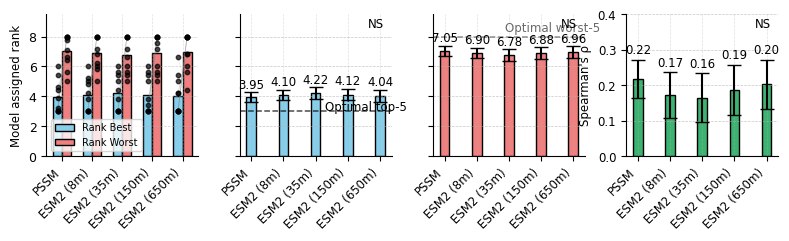

Figure saved to refined_figures/figure_screen_analysis/rank_4panel.svg


In [12]:
mut_ranks_all_df = pd.DataFrame(mut_ranks_all)
mut_ranks_all_df[mut_ranks_all_df["hybrid"] == True]

from scipy.stats import f_oneway

# Run ANOVA and keep results for significance codes
def get_anova_p(variable, data_frame):
    groups = [data_frame[data_frame["model"] == model][variable].values for model in data_frame["model"].unique()]
    if any(len(g) == 0 for g in groups):
        return None
    _, p_val = f_oneway(*groups)
    return p_val

anova_pvals = {
    "ranks_best": get_anova_p("ranks_best", mut_ranks_all_df),
    "ranks_worst": get_anova_p("ranks_worst", mut_ranks_all_df),
    "empirical_vs_model_prob_spearmanr": get_anova_p("empirical_vs_model_prob_spearmanr", mut_ranks_all_df),
}
def sig_code(p):
    if p is None: return ""
    return "NS" if p > 0.05 else "*"

# Plotting
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams.update({'font.size': 8.5})

fig_width = 8
fig_height = 2
n_models = len(mut_ranks_all_df["model"].unique())
bar_width = 0.3

# Use subplots for 4 panels, 1 row, NO excessive space
fig, axes = plt.subplots(1, 4, figsize=(fig_width, fig_height), sharey=False)

# Reduce whitespace (set wspace to a small value)
plt.subplots_adjust(wspace=0.27, left=0.065, right=0.98, bottom=0.26, top=0.97)

# Common data
x_order = mut_ranks_all_df["model"].unique()
x_labels = [names_dict.get(model, model) for model in x_order]
x = np.arange(len(x_order))
color_best = "skyblue"
color_worst = "lightcoral"

# 1. --- Subplot 1: Best + Worst, points/lines ---
ax0 = axes[0]
means_best = mut_ranks_all_df.groupby("model")["ranks_best"].mean().reindex(x_order)
means_worst = mut_ranks_all_df.groupby("model")["ranks_worst"].mean().reindex(x_order)

bars_best = ax0.bar(x - bar_width/2, means_best, width=bar_width, color=color_best, edgecolor="black", label="Rank Best")
bars_worst = ax0.bar(x + bar_width/2, means_worst, width=bar_width, color=color_worst, edgecolor="black", label="Rank Worst")

for i, model in enumerate(x_order):
    model_df = mut_ranks_all_df[mut_ranks_all_df["model"] == model]
    # Best
    ax0.scatter(
        np.full(model_df.shape[0], x[i] - bar_width/2),
        model_df["ranks_best"], color="black", alpha=0.7, s=10, marker="o", zorder=4
    )
    # Worst
    ax0.scatter(
        np.full(model_df.shape[0], x[i] + bar_width/2),
        model_df["ranks_worst"], color="black", alpha=0.7, s=10, marker="o", zorder=4
    )
    for idx, row in model_df.iterrows():
        ax0.plot(
            [x[i] - bar_width/2, x[i] + bar_width/2],
            [row["ranks_best"], row["ranks_worst"]],
            color="gray", alpha=0.2, zorder=2, linewidth=0.5
        )

ax0.set_ylabel("Model assigned rank", fontsize=8.5)
ax0.set_xticks(x)
ax0.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax0.legend(loc="best", fontsize=7)
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax0.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax0.set_ylim(0, 9.5)
for label in ax0.get_yticklabels():
    label.set_fontsize(9)

# 2. --- Subplot 2: Best mean ± SEM, numbers ---
ax1 = axes[1]
means_best = mut_ranks_all_df.groupby("model")["ranks_best"].mean().reindex(x_order)
sem_best = mut_ranks_all_df.groupby("model")["ranks_best"].sem().reindex(x_order)
bars1 = ax1.bar(x, means_best, yerr=sem_best, width=bar_width, color=color_best, edgecolor="black", capsize=5)
for i, (mean_val, sem_val) in enumerate(zip(means_best, sem_best)):
    ax1.text(i, mean_val + sem_val + 0.08, f"{mean_val:.2f}", ha="center", va="bottom", fontsize=8.5)

ax1.set_ylim(0, 9.5)
ax1.set_yticklabels([])
ax1.axhline(3, ls="--", c="black", lw=1.1, alpha=0.7)
ax1.text(len(x_order)-0.15, 3 - 0.13, "Optimal top-5", color="black", fontsize=8.5, ha="right", va="bottom")
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax1.set_xlabel("", fontsize=8.5)
for label in ax1.get_yticklabels():
    label.set_fontsize(8)
ax1.text(0.95, 0.98, sig_code(anova_pvals['ranks_best']), fontsize=8.5, ha="right", va="top", transform=ax1.transAxes)

# 3. --- Subplot 3: Worst mean ± SEM, numbers ---
ax2 = axes[2]
means_worst = mut_ranks_all_df.groupby("model")["ranks_worst"].mean().reindex(x_order)
sem_worst = mut_ranks_all_df.groupby("model")["ranks_worst"].sem().reindex(x_order)
bars2 = ax2.bar(x, means_worst, yerr=sem_worst, width=bar_width, color=color_worst, edgecolor="black", capsize=5)
for i, (mean_val, sem_val) in enumerate(zip(means_worst, sem_worst)):
    ax2.text(i, mean_val + sem_val + 0.08, f"{mean_val:.2f}", ha="center", va="bottom", fontsize=8.5)

ax2.set_ylim(0, 9.5)
ax2.set_yticklabels([])
ax2.axhline(8, ls="--", c="dimgrey", lw=1.1, alpha=0.75)
ax2.text(len(x_order)-0.15, 8 + 0.13, "Optimal worst-5", color="dimgrey", fontsize=8.5, ha="right", va="bottom")
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax2.set_xlabel("", fontsize=8.5)
for label in ax2.get_yticklabels():
    label.set_fontsize(8)
ax2.text(0.95, 0.98, sig_code(anova_pvals['ranks_worst']), fontsize=8.5, ha="right", va="top", transform=ax2.transAxes)

# 4. --- Subplot 4: Spearman, mean ± SEM, numbers ---
ax3 = axes[3]
means_spearmanr = mut_ranks_all_df.groupby("model")["empirical_vs_model_prob_spearmanr"].mean().reindex(x_order)
sem_spearmanr = mut_ranks_all_df.groupby("model")["empirical_vs_model_prob_spearmanr"].sem().reindex(x_order)
bars3 = ax3.bar(x, means_spearmanr, yerr=sem_spearmanr, width=bar_width, color="mediumseagreen", edgecolor="black", capsize=5)
for i, (mean_val, sem_val) in enumerate(zip(means_spearmanr, sem_spearmanr)):
    ax3.text(i, mean_val + (sem_val if mean_val > 0 else -sem_val) + 0.01 * (1 if mean_val > 0 else -1),
             f"{mean_val:.2f}", ha="center", va="bottom" if mean_val > 0 else "top", fontsize=8.5)

ax3.set_xticks(x)
ax3.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax3.set_ylabel("Spearman's ρ", fontsize=8.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax3.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax3.set_xlabel("", fontsize=8.5)
ax3.set_ylim(0, 0.4)
for label in ax3.get_yticklabels():
    label.set_fontsize(8.5)
ax3.text(0.95, 0.98, sig_code(anova_pvals['empirical_vs_model_prob_spearmanr']), fontsize=8.5, ha="right", va="top", transform=ax3.transAxes)

# Save and show
# tight_layout is not needed since we adjust wspace, left, right directly
fig_out_dir = os.path.join("refined_figures", "figure_screen_analysis")
os.makedirs(fig_out_dir, exist_ok=True)
svg_path = os.path.join(fig_out_dir, "rank_4panel.svg")

fig.savefig(svg_path, format="svg")
plt.show()
print(f"Figure saved to {svg_path}")


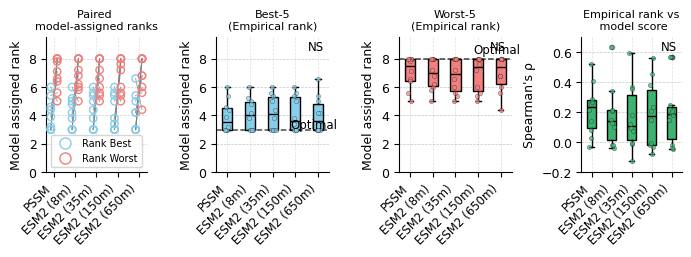

Figure saved to refined_figures/figure_screen_analysis/rank_4panel_boxplot.svg


In [13]:
mut_ranks_all_df = pd.DataFrame(mut_ranks_all)
mut_ranks_all_df[mut_ranks_all_df["hybrid"] == False]

from scipy.stats import f_oneway

# Scatter marker mapping for models (customize as needed)
# Example dictionary (replace/update as desired):
model_marker_dict = {
    "modelA": "o",
    "modelB": "s",
    "modelC": "D",
    "modelD": "^",
    "default": "o"
}
def get_marker(model):
    return model_marker_dict.get(model, model_marker_dict["default"])

# Run ANOVA and keep results for significance codes
def get_anova_p(variable, data_frame):
    groups = [data_frame[data_frame["model"] == model][variable].values for model in data_frame["model"].unique()]
    if any(len(g) == 0 for g in groups):
        return None
    _, p_val = f_oneway(*groups)
    return p_val

anova_pvals = {
    "ranks_best": get_anova_p("ranks_best", mut_ranks_all_df),
    "ranks_worst": get_anova_p("ranks_worst", mut_ranks_all_df),
    "empirical_vs_model_prob_spearmanr": get_anova_p("empirical_vs_model_prob_spearmanr", mut_ranks_all_df),
}
def sig_code(p):
    if p is None: return ""
    return "NS" if p > 0.05 else "*"

# Plotting
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams.update({'font.size': 8.5})

fig_width = 8.2
fig_height = 1.75
n_models = len(mut_ranks_all_df["model"].unique())

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(fig_width, fig_height))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1.13, 1.13, 1], wspace=0.65)
axes = [fig.add_subplot(gs[i]) for i in range(4)]

x_order = mut_ranks_all_df["model"].unique()
x_labels = [names_dict.get(model, model) for model in x_order]
color_best = "skyblue"
color_worst = "lightcoral"

# --- Subplot 1: Paired dots with custom markers ---
ax0 = axes[0]
positions_best = np.arange(len(x_order)) - 0.15
positions_worst = np.arange(len(x_order)) + 0.15

model_list = list(x_order)
for i, model in enumerate(model_list):
    marker = get_marker(model)
    x_b = positions_best[i]
    x_w = positions_worst[i]
    vals_best = mut_ranks_all_df.loc[mut_ranks_all_df["model"]==model, "ranks_best"].dropna()
    vals_worst = mut_ranks_all_df.loc[mut_ranks_all_df["model"]==model, "ranks_worst"].dropna()
    shared_idx = vals_best.index.intersection(vals_worst.index)
    vals_best_al = vals_best.loc[shared_idx].values
    vals_worst_al = vals_worst.loc[shared_idx].values
    ax0.scatter([x_b]*len(vals_best_al), vals_best_al, marker=marker, s=28, facecolors='none', edgecolors=color_best, linewidth=1, alpha=1, zorder=3, label=None)
    ax0.scatter([x_w]*len(vals_worst_al), vals_worst_al, marker=marker, s=28, facecolors='none', edgecolors=color_worst, linewidth=1, alpha=1, zorder=3, label=None)
    for vb, vw in zip(vals_best_al, vals_worst_al):
        ax0.plot([x_b, x_w], [vb, vw], color='gray', lw=0.7, alpha=0.7, zorder=2)

ax0.set_title("Paired \nmodel-assigned ranks", fontsize=8)
ax0.set_ylabel("Model assigned rank", fontsize=9)
ax0.set_xticks(np.arange(len(x_order)))
ax0.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax0.legend([plt.Line2D([0], [0], marker=model_marker_dict.get(x_order[0], "o"), color=color_best, lw=0, markerfacecolor='none', markeredgecolor=color_best, markersize=8),
            plt.Line2D([0], [0], marker=model_marker_dict.get(x_order[0], "o"), color=color_worst, lw=0, markerfacecolor='none', markeredgecolor=color_worst, markersize=8)],
           ["Rank Best", "Rank Worst"], loc="best", fontsize=7, frameon=True)
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax0.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax0.set_ylim(0, 9.5)
for label in ax0.get_yticklabels():
    label.set_fontsize(9)

# --- Subplot 2: Best rank boxplot + custom marker scatter ---
data_best = [mut_ranks_all_df.loc[mut_ranks_all_df["model"]==model, "ranks_best"].dropna().values for model in x_order]
ax1 = axes[1]
box1 = ax1.boxplot(data_best, positions=np.arange(len(x_order)), widths=0.45, patch_artist=True,
                   boxprops=dict(facecolor=color_best, color="black"),
                   medianprops=dict(color="black"),
                   flierprops=dict(markerfacecolor=color_best, marker="o", markersize=3, alpha=0.4))
rng = np.random.default_rng(12345)
for i, (vals, model) in enumerate(zip(data_best, x_order)):
    jitter = rng.normal(loc=i, scale=0.055, size=len(vals))
    marker = get_marker(model)
    ax1.scatter(jitter, vals, marker=marker, color=color_best, s=10, alpha=0.7, edgecolor='k', linewidth=0.25, zorder=3)

ax1.set_title("Best-5\n(Empirical rank)", fontsize=8)
ax1.set_ylim(0, 9.5)
ax1.axhline(3, ls="--", c="black", lw=1.1, alpha=0.7)
ax1.text(len(x_order)-0.15, 3 - 0.13, "Optimal", color="black", fontsize=8.5, ha="right", va="bottom")
ax1.set_xticks(np.arange(len(x_order)))
ax1.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax1.set_xlabel("", fontsize=8.5)
for label in ax1.get_yticklabels():
    label.set_fontsize(9)
ax1.set_ylabel("Model assigned rank", fontsize=9)
ax1.text(0.95, 0.98, sig_code(anova_pvals['ranks_best']), fontsize=8.5, ha="right", va="top", transform=ax1.transAxes)

# --- Subplot 3: Worst rank boxplot + custom marker scatter ---
data_worst = [mut_ranks_all_df.loc[mut_ranks_all_df["model"]==model, "ranks_worst"].dropna().values for model in x_order]
ax2 = axes[2]
box2 = ax2.boxplot(data_worst, positions=np.arange(len(x_order)), widths=0.45, patch_artist=True,
                   boxprops=dict(facecolor=color_worst, color="black"),
                   medianprops=dict(color="black"),
                   flierprops=dict(markerfacecolor=color_worst, marker="o", markersize=3, alpha=0.4))

for i, (vals, model) in enumerate(zip(data_worst, x_order)):
    jitter = rng.normal(loc=i, scale=0.055, size=len(vals))
    marker = get_marker(model)
    ax2.scatter(jitter, vals, marker=marker, color=color_worst, s=10, alpha=0.7, edgecolor='k', linewidth=0.25, zorder=3)

ax2.set_title("Worst-5\n(Empirical rank)", fontsize=8)
ax2.set_ylim(0, 9.5)
ax2.axhline(8, ls="--", c="black", lw=1.1, alpha=0.75)
ax2.text(len(x_order)-0.15, 8 + 0.13, "Optimal", color="black", fontsize=8.5, ha="right", va="bottom")
ax2.set_xticks(np.arange(len(x_order)))
ax2.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax2.set_xlabel("", fontsize=8.5)
for label in ax2.get_yticklabels():
    label.set_fontsize(9)
ax2.set_ylabel("Model assigned rank", fontsize=9)
ax2.text(0.95, 0.98, sig_code(anova_pvals['ranks_worst']), fontsize=8.5, ha="right", va="top", transform=ax2.transAxes)

# --- Subplot 4: Spearman boxplot + custom marker scatter ---
data_spearman = [mut_ranks_all_df.loc[mut_ranks_all_df["model"]==model, "empirical_vs_model_prob_spearmanr"].dropna() for model in x_order]
ax3 = axes[3]
box3 = ax3.boxplot(data_spearman, positions=np.arange(len(x_order)), widths=0.45, patch_artist=True,
                   boxprops=dict(facecolor="mediumseagreen", color="black"),
                   medianprops=dict(color="black"),
                   flierprops=dict(markerfacecolor="mediumseagreen", marker="o", markersize=3, alpha=0.4))

for i, (vals, model) in enumerate(zip(data_spearman, x_order)):
    jitter = rng.normal(loc=i, scale=0.055, size=len(vals))
    marker = get_marker(model)
    ax3.scatter(jitter, vals, marker=marker, color="mediumseagreen", s=10, alpha=0.7, edgecolor='k', linewidth=0.25, zorder=3)

ax3.set_xticks(np.arange(len(x_order)))
ax3.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8.5)
ax3.set_ylabel("Spearman's ρ", fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax3.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax3.set_xlabel("", fontsize=8.5)
ax3.set_ylim(-0.2, 0.7)
ax3.set_title("Empirical rank vs\n model score", fontsize=8)
for label in ax3.get_yticklabels():
    label.set_fontsize(9)
ax3.text(0.95, 0.98, sig_code(anova_pvals['empirical_vs_model_prob_spearmanr']), fontsize=8.5, ha="right", va="top", transform=ax3.transAxes)

# Save and show
fig_out_dir = os.path.join("refined_figures", "figure_screen_analysis")
os.makedirs(fig_out_dir, exist_ok=True)
svg_path = os.path.join(fig_out_dir, "rank_4panel_boxplot.svg")

fig.savefig(svg_path, format="svg")
plt.show()
print(f"Figure saved to {svg_path}")


=== ANOVA (f_oneway): Ranks Best by Model ===
F-statistic = 0.0702, p-value = 0.9907
Models: ['pssm', 'esm2_t6_8M_UR50D', 'esm2_t12_35M_UR50D', 'esm2_t30_150M_UR50D', 'esm2_t33_650M_UR50D']

=== ANOVA (f_oneway): Ranks Worst by Model ===
F-statistic = 0.0702, p-value = 0.9907
Models: ['pssm', 'esm2_t6_8M_UR50D', 'esm2_t12_35M_UR50D', 'esm2_t30_150M_UR50D', 'esm2_t33_650M_UR50D']

=== ANOVA (f_oneway): Empirical Vs Model Prob Spearmanr by Model ===
F-statistic = 0.1104, p-value = 0.9783
Models: ['pssm', 'esm2_t6_8M_UR50D', 'esm2_t12_35M_UR50D', 'esm2_t30_150M_UR50D', 'esm2_t33_650M_UR50D']



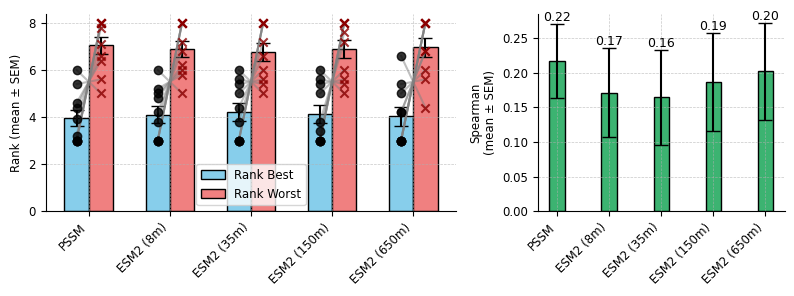

Figure saved to refined_figures/figure_screen_analysis/rank.svg


In [14]:
mut_ranks_all_df = pd.DataFrame(mut_ranks_all)
mut_ranks_all_df[mut_ranks_all_df["hybrid"] == True]

# ==== 1. Run ANOVA tests between models for each variable using scipy.stats.f_oneway ====
from scipy.stats import f_oneway

# Take the absolute value for SpearmanR for the ANOVA (if desired)
mut_ranks_all_df["empirical_vs_model_prob_spearmanr"] = mut_ranks_all_df["empirical_vs_model_prob_spearmanr"]

def print_f_oneway_anova(variable, data_frame):
    groups = []
    group_labels = data_frame["model"].unique()
    for model in group_labels:
        groups.append(data_frame[data_frame["model"] == model][variable].values)
    f_stat, p_val = f_oneway(*groups)
    print(f"=== ANOVA (f_oneway): {variable.replace('_', ' ').title()} by Model ===")
    print(f"F-statistic = {f_stat:.4f}, p-value = {p_val:.4g}")
    print(f"Models: {list(group_labels)}")
    print()

print_f_oneway_anova("ranks_best", mut_ranks_all_df)
print_f_oneway_anova("ranks_worst", mut_ranks_all_df)
print_f_oneway_anova("empirical_vs_model_prob_spearmanr", mut_ranks_all_df)

# Ensure SVG text uses font, not paths (don't convert text to outlines)
plt.rcParams['svg.fonttype'] = 'none'

fig = plt.figure(figsize=(8, 3))
gs = gridspec.GridSpec(1, 2, width_ratios=[5, 3])

ax0 = plt.subplot(gs[0])
# Make the bars thinner by reducing bar_width
bar_width = 0.3
x_order = mut_ranks_all_df["model"].unique()
x = np.arange(len(x_order))

means_best = mut_ranks_all_df.groupby("model")["ranks_best"].mean().reindex(x_order)
means_worst = mut_ranks_all_df.groupby("model")["ranks_worst"].mean().reindex(x_order)
sem_best = mut_ranks_all_df.groupby("model")["ranks_best"].sem().reindex(x_order)
sem_worst = mut_ranks_all_df.groupby("model")["ranks_worst"].sem().reindex(x_order)
x_labels = [names_dict.get(model, model) for model in x_order]

ax0.bar(x - bar_width/2, means_best, yerr=sem_best, width=bar_width, color="skyblue", edgecolor="black", label="Rank Best", capsize=5)
ax0.bar(x + bar_width/2, means_worst, yerr=sem_worst, width=bar_width, color="lightcoral", edgecolor="black", label="Rank Worst", capsize=5)

for i, model in enumerate(x_order):
    model_df = mut_ranks_all_df[mut_ranks_all_df["model"] == model]
    for _, row in model_df.iterrows():
        ax0.plot(
            [x[i] - bar_width/2, x[i] + bar_width/2],
            [row["ranks_best"], row["ranks_worst"]],
            color="gray", alpha=0.5, zorder=3
        )
        ax0.scatter(x[i] - bar_width/2, row["ranks_best"], color="black", alpha=0.8, marker="o", zorder=4)
        ax0.scatter(x[i] + bar_width/2, row["ranks_worst"], color="darkred", alpha=0.8, marker="x", zorder=4)

ax0.set_ylabel("Rank (mean ± SEM)")
ax0.set_xticks(x)
ax0.set_xticklabels(x_labels, rotation=45, ha="right")
ax0.legend()

# Remove top and right spines, and add gridlines for ax0
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax0.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

ax1 = plt.subplot(gs[1])
model_order = x_order
model_labels = [names_dict.get(model, model) for model in model_order]

means_spearmanr = mut_ranks_all_df.groupby("model")["empirical_vs_model_prob_spearmanr"].mean().reindex(model_order)
sem_spearmanr = mut_ranks_all_df.groupby("model")["empirical_vs_model_prob_spearmanr"].sem().reindex(model_order)
x2 = np.arange(len(model_order))

# Make these bars thinner as well by reducing width from 0.6 to 0.3
ax1.bar(x2, means_spearmanr, yerr=sem_spearmanr, width=0.3, color="mediumseagreen", edgecolor="black", capsize=5)

for i, (mean_val, sem_val) in enumerate(zip(means_spearmanr, sem_spearmanr)):
    ax1.text(i, mean_val + (sem_val if mean_val > 0 else -sem_val), f"{mean_val:.2f}", ha="center", va="bottom" if mean_val > 0 else "top", fontsize=9)
ax1.set_ylabel("Spearman\n(mean ± SEM)")
ax1.set_xticks(x2)
ax1.set_xticklabels(model_labels, rotation=45, ha="right")

# Remove top and right spines, and add gridlines for ax1
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

# Prepare output directory and save path
fig_out_dir = os.path.join("refined_figures", "figure_screen_analysis")
os.makedirs(fig_out_dir, exist_ok=True)
svg_path = os.path.join(fig_out_dir, "rank.svg")

fig.savefig(svg_path, format="svg")
plt.show()
print(f"Figure saved to {svg_path}")


/tmp/ipykernel_2938245/2244136191.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df["short_model"] = subset_df["model"].map(lambda m: names_dict.get(m, m))
/tmp/ipykernel_2938245/2244136191.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df["dataset_model"] = subset_df["dataset"] + " / " + subset_df["short_model"]
/tmp/ipykernel_2938245/2244136191.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

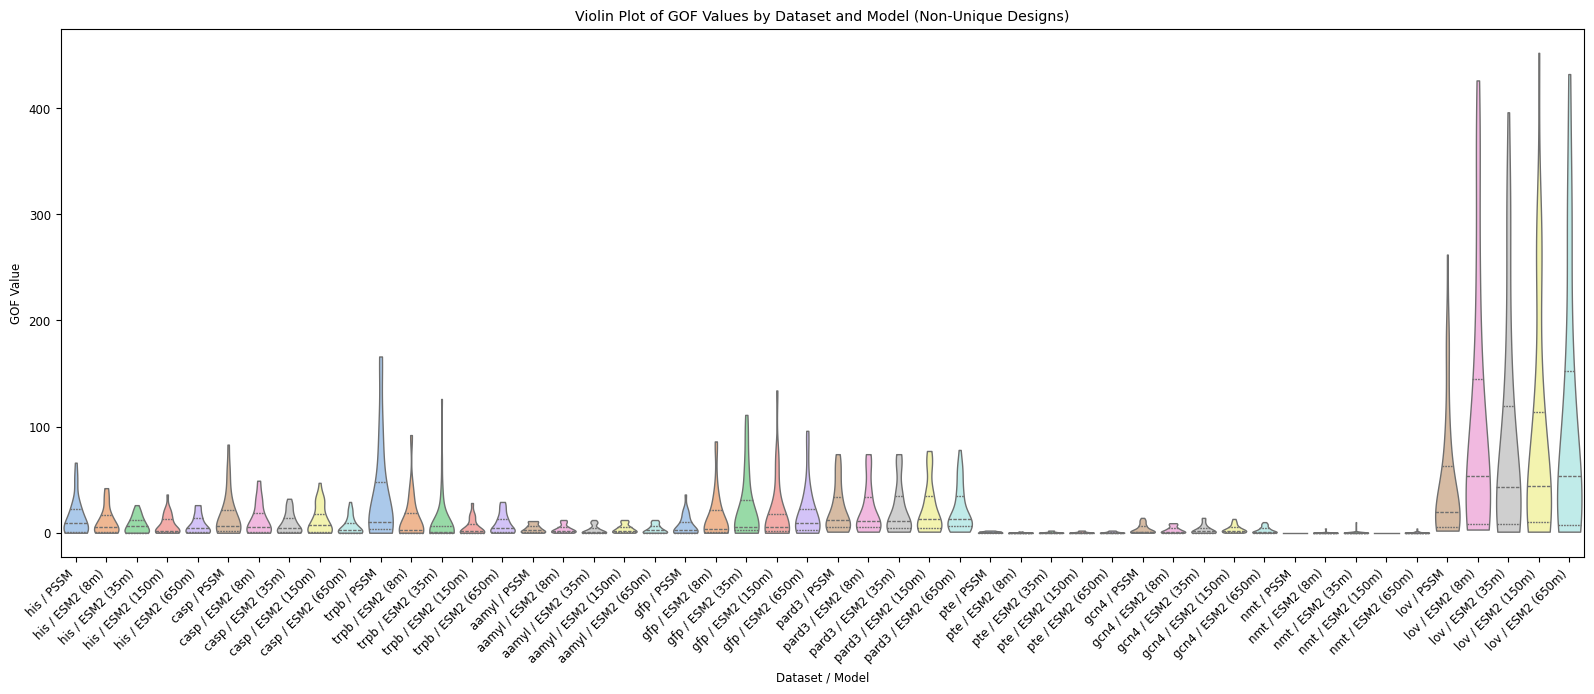

In [15]:
results_df = pd.concat(df_all)
results_df.columns

import seaborn as sns
import matplotlib.pyplot as plt

# Subset results_df for metric == "gof" and unique == False
subset_df = results_df[(results_df["metric"] == "gof") & (results_df["unique"] == True) & (results_df["normalized"] == False) & (results_df["hybrid"] == False)]

# Create a new column that combines dataset and model for grouped violin plots, using short model names from names_dict
subset_df["short_model"] = subset_df["model"].map(lambda m: names_dict.get(m, m))
subset_df["dataset_model"] = subset_df["dataset"] + " / " + subset_df["short_model"]

# Get all short model names in the order they first appear per dataset
models_per_dataset = {
    ds: subset_df[subset_df["dataset"] == ds]["short_model"].unique()
    for ds in dataset_order
}

# Create the ordered x-axis: for each dataset, append its dataset/model-shortname combinations in order
ordered_dataset_models = []
for ds in dataset_order:
    for short_model in models_per_dataset[ds]:
        ordered_dataset_models.append(f"{ds} / {short_model}")

# Make the new column categorical with our ordering
subset_df["dataset_model"] = pd.Categorical(subset_df["dataset_model"], categories=ordered_dataset_models, ordered=True)

plt.figure(figsize=(16, 7))
sns.violinplot(
    x="dataset_model",
    y="value",
    data=subset_df,
    order=ordered_dataset_models,
    cut=0,  # don't extend beyond observed data
    scale="width",  # for equal width violins
    inner="quart",  # show quartiles within the violins
    linewidth=1,
    palette="pastel"
)
plt.xlabel("Dataset / Model")
plt.ylabel("GOF Value")
plt.title("Violin Plot of GOF Values by Dataset and Model (Non-Unique Designs)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


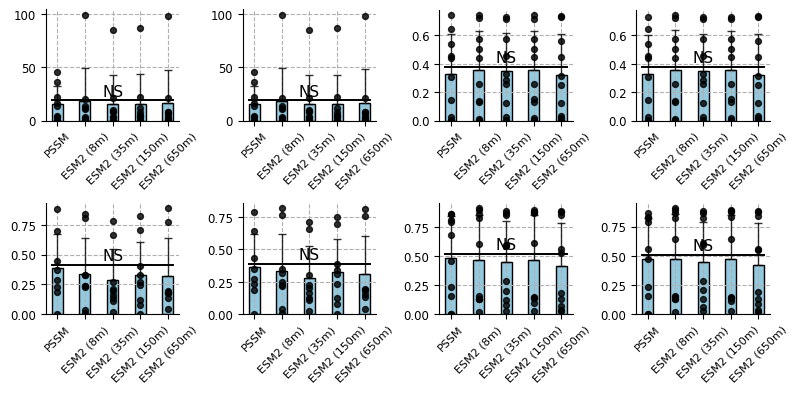

Figure saved to refined_figures/figure_screen_analysis/comparision_of_navigation_with_x_labels.svg

Friedman test and ANOVA results (per panel):
GOF (non-unique) | norm=False: Friedman test: chi2=4.42, p=3.52e-01 (NS) | ANOVA: F=0.03, p=9.98e-01 (NS)
GOF (unique) | norm=False: Friedman test: chi2=4.17, p=3.83e-01 (NS) | ANOVA: F=0.04, p=9.97e-01 (NS)
Median Activity (non-unique) | norm=False: Friedman test: chi2=2.57, p=6.32e-01 (NS) | ANOVA: F=0.00, p=1.00e+00 (NS)
Median Activity (unique) | norm=False: Friedman test: chi2=2.54, p=6.38e-01 (NS) | ANOVA: F=0.00, p=1.00e+00 (NS)
GOF (non-unique) | norm=True: Friedman test: chi2=7.70, p=1.03e-01 (NS) | ANOVA: F=0.23, p=9.18e-01 (NS)
GOF (unique) | norm=True: Friedman test: chi2=8.70, p=6.90e-02 (NS) | ANOVA: F=0.22, p=9.28e-01 (NS)
Median Activity (non-unique) | norm=True: Friedman test: chi2=2.40, p=6.63e-01 (NS) | ANOVA: F=0.01, p=1.00e+00 (NS)
Median Activity (unique) | norm=True: Friedman test: chi2=1.51, p=8.25e-01 (NS) | ANOVA: F=0

In [16]:

results_df = pd.concat(df_all)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import f_oneway
import os

# For consistent order and labels
x_labels = ["PSSM", "ESM2 (8m)", "ESM2 (35m)", "ESM2 (150m)", "ESM2 (650m)"]

fig, axes = plt.subplots(2, 4, figsize=(8, 4))  # 2 rows (normalized), 4 cols (metric/unique combos)

settings_combinations = [
    ("gof", False, False, "GOF (non-unique)"),
    ("gof", True, False, "GOF (unique)"),
    ("median_activity", False, False, "Median Activity (non-unique)"),
    ("median_activity", True, False, "Median Activity (unique)")
]
test_results = []

# For each normalized row and metric/unique combo column
for norm_idx, normalized in enumerate([False, True]):
    for col_idx, (metric_to_use, unique, _, panel_title) in enumerate(settings_combinations):
        ax = axes[norm_idx, col_idx]
        # Subset data
        if metric_to_use == "gof":
            subset_df = results_df[
                (results_df["metric"] == metric_to_use) &
                (results_df["unique"] == unique) &
                (results_df["dataset"] != "gfp") &
                (results_df["normalized"] == normalized) &
                (results_df["hybrid"] == False)

            ]
        else:
            subset_df = results_df[
                (results_df["metric"] == metric_to_use) &
                (results_df["unique"] == unique) &
                (results_df["normalized"] == normalized) & 
                (results_df["hybrid"] == False)
            ]
        # For each (dataset, model), compute the median value, mean and SEM (not SD)
        grouped = subset_df.groupby(["dataset", "model"])["value"]
        stats_df = grouped.agg(
            median='median',
            mean='mean',
            sem=lambda x: np.std(x, ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0.0
        ).reset_index()
        label_to_code = {names_dict.get(model, model): model for model in stats_df["model"].unique()}
        x_order = [label_to_code[label] for label in x_labels if label in label_to_code]
        short_order = [names_dict.get(model, model) for model in x_order]

        # Barplot with even narrower width -- using the model-wide mean across all datasets
        model_means = stats_df.groupby("model")["mean"].mean().reindex(x_order)
        model_stds = stats_df.groupby("model")["mean"].std().reindex(x_order)
        # Only plot "+" error (mean + std)
        upper_err = model_stds.values
        # Remove lower error: only + std (show bar from mean up, not from mean down)
        yerr = [np.zeros_like(upper_err), upper_err]  # lower, upper

        sns.barplot(
            x=short_order,
            y=model_means.values,
            ax=ax,
            color="skyblue",
            edgecolor="black",
            width=0.4,
            errorbar=None  # No error bars from seaborn, we add "+" bars manually
        )
        # Add only "+" std error bars (asymmetric: lower error is 0)
        ax.errorbar(
            x=np.arange(len(short_order)),
            y=model_means.values,
            yerr=[np.zeros_like(upper_err), upper_err],  # asymmetric: [low, high]
            fmt='none',
            ecolor='black',
            elinewidth=1.0,
            capsize=3,
            capthick=1.0,
            alpha=0.8
        )
        # Overlay scatter per dataset, in black color, and NO error bars
        for i, model in enumerate(x_order):
            # Collect all dataset means for this model
            dataset_means = stats_df[stats_df["model"] == model]["mean"].values
            ax.scatter(
                [i] * len(dataset_means),
                dataset_means,
                color="black",
                s=18,
                alpha=0.8,
                zorder=15,
                label=None
            )
        ax.set_xticks(range(len(short_order)))
        ax.set_xticklabels(short_order, rotation=45, fontsize=8)
        ax.set_xlabel("")
        ax.grid(True, axis='y', linestyle='--')
        ax.grid(True, axis='x', linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Y-labels leftmost and col==2 for clarity
        if col_idx == 0:
            ylabel = "GOF" if metric_to_use=="gof" else "Median Activity"
            ax.set_ylabel("")
        elif col_idx == 2:
            ylabel = "GOF" if metric_to_use=="gof" else "Median Activity"
            ax.set_ylabel("")
        else:
            ax.set_ylabel("")
        # Statistics (keep)
        data_wide = stats_df.pivot(index="dataset", columns="model", values="median")
        data_wide = data_wide.reindex(columns=x_order)
        data_wide = data_wide.dropna(axis=0)
        n_models = data_wide.shape[1]
        n_datasets = data_wide.shape[0]
        friedman_msg = None
        anova_msg = None
        friedman_pval = None
        anova_pval = None
        ns_line_plotted = False
        if n_models >= 2 and n_datasets >= 2:
            try:
                friedman_input = [data_wide.iloc[:, i].values for i in range(n_models)]
                stat_friedman, p_friedman = stats.friedmanchisquare(*friedman_input)
                friedman_pval = p_friedman
                ns_needed = False
                if p_friedman > 0.05:
                    friedman_msg = f"Friedman test: chi2={stat_friedman:.2f}, p={p_friedman:.2e} (NS)"
                    ns_needed = True
                else:
                    friedman_msg = f"Friedman test: chi2={stat_friedman:.2f}, p={p_friedman:.2e}"
            except Exception as e:
                friedman_msg = f"Friedman test could not be computed: {e}"
                ns_needed = False
            try:
                stat_anova, p_anova = f_oneway(*friedman_input)
                anova_pval = p_anova
                if p_anova > 0.05:
                    anova_msg = f"ANOVA: F={stat_anova:.2f}, p={p_anova:.2e} (NS)"
                    ns_needed = True
                else:
                    anova_msg = f"ANOVA: F={stat_anova:.2f}, p={p_anova:.2e}"
            except Exception as e:
                anova_msg = f"ANOVA could not be computed: {e}"
            msg = f"{panel_title} | norm={normalized}: {friedman_msg} | {anova_msg}"
            test_results.append(msg)
            # Draw NS annotation and horizontal line above all boxes if not significant in either test
            if ns_needed:
                # Horizontal line y location
                ymin = np.nanmax(model_means.values)
                if np.isnan(ymin):
                    ymin = 0.0
                y_ns = ymin * 1.07 if ymin > 0 else 0.05

                # Line: from leftmost bar edge to rightmost bar edge, slightly wider than bar positions
                x_left = -0.2
                x_right = len(short_order)-1+0.2
                ax.plot([x_left, x_right], [y_ns, y_ns], lw=1.4, color="black", clip_on=False, zorder=20)
                # Centered NS
                ax.text((x_left + x_right)/2, y_ns + 0.03*y_ns if y_ns != 0 else 0.03,
                        "NS", ha='center', va='bottom', color='black', fontsize=11, zorder=21)
        else:
            test_results.append(f"{panel_title} | norm={normalized}: Not enough data for Friedman test or ANOVA.")

# DO NOT show any legends
for row in axes:
    for ax in row:
        ax.legend_.remove() if hasattr(ax, 'legend_') and ax.legend_ is not None else None

plt.tight_layout()

# Prepare output directory and save figure as SVG
fig_out_dir = os.path.join("refined_figures", "figure_screen_analysis")
os.makedirs(fig_out_dir, exist_ok=True)
svg_path = os.path.join(fig_out_dir, "comparision_of_navigation_with_x_labels.svg")

fig.savefig(svg_path, format="svg")
plt.show()
print(f"Figure saved to {svg_path}")

print("\nFriedman test and ANOVA results (per panel):")
for result in test_results:
    print(result)


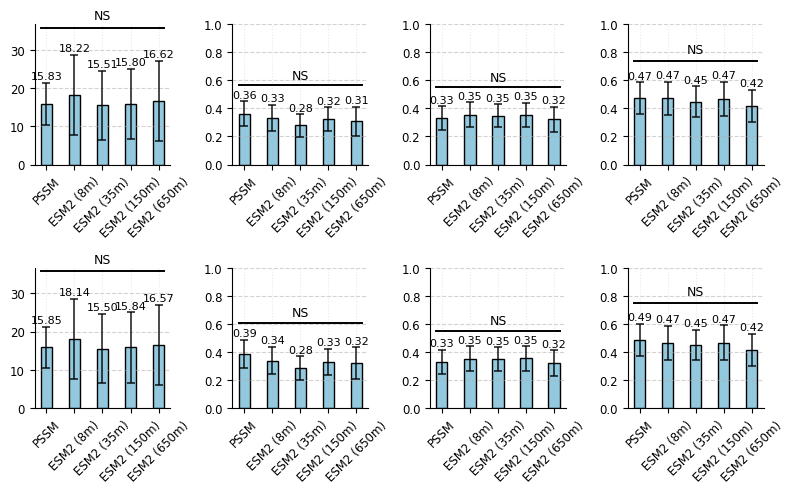

Figure saved to refined_figures/figure_screen_analysis/bar_goff_activity_unique_nonunique_ordered.svg

Friedman test and ANOVA results (per panel):
#GOF (unique) | norm=False: None | ANOVA: F=0.02, p=1.00e+00 (NS)
Normalized #GOF (unique) | norm=True: None | ANOVA: F=0.02, p=1.00e+00 (NS)
Activity (unique) | norm=False: None | ANOVA: F=0.02, p=1.00e+00 (NS)
Normalized Activity (unique) | norm=True: None | ANOVA: F=0.02, p=1.00e+00 (NS)
#GOF (non-unique) | norm=False: None | ANOVA: F=0.02, p=1.00e+00 (NS)
Normalized #GOF (non-unique) | norm=True: None | ANOVA: F=0.02, p=1.00e+00 (NS)
Activity (non-unique) | norm=False: None | ANOVA: F=0.02, p=1.00e+00 (NS)
Normalized Activity (non-unique) | norm=True: None | ANOVA: F=0.02, p=1.00e+00 (NS)


In [17]:

results_df = pd.concat(df_all)

# For consistent order and labels
x_labels = ["PSSM", "ESM2 (8m)", "ESM2 (35m)", "ESM2 (150m)", "ESM2 (650m)"]

# Layout: (top) 0: unique GOF, 1: unique normalized GOF, 2: unique activity, 3: unique normalized activity,
#         (bottom) 4: non-unique GOF, 5: non-unique normalized GOF, 6: non-unique activity, 7: non-unique normalized activity
panel_settings = [
    # col, row, metric, normalized, unique, panel_title
    (0, 0, "gof", False, True, "#GOF (unique)"),
    (1, 0, "gof", True, True, "Normalized #GOF (unique)"),
    (2, 0, "median_activity", False, True, "Activity (unique)"),
    (3, 0, "median_activity", True, True, "Normalized Activity (unique)"),
    (0, 1, "gof", False, False, "#GOF (non-unique)"),
    (1, 1, "gof", True, False, "Normalized #GOF (non-unique)"),
    (2, 1, "median_activity", False, False, "Activity (non-unique)"),
    (3, 1, "median_activity", True, False, "Normalized Activity (non-unique)"),
]

fig, axes = plt.subplots(2, 4, figsize=(8,5))  # order: [row, col] for y, x

test_results = []

for col, row, metric_to_use, normalized, unique, panel_title in panel_settings:
    ax = axes[row, col]
    
    # Subset data
    if metric_to_use == "gof":
        subset_df = results_df[
            (results_df["metric"] == metric_to_use) &
            (results_df["unique"] == unique) &
            (results_df["dataset"] != "gfp") &
            (results_df["normalized"] == normalized) &
            (results_df["hybrid"] == False)
        ]
    else:
        subset_df = results_df[
            (results_df["metric"] == metric_to_use) &
            (results_df["unique"] == unique) &
            (results_df["normalized"] == normalized) &
            (results_df["hybrid"] == False)
        ]
    # For each (dataset, model), compute the median value, mean and SEM (not SD)
    grouped = subset_df.groupby(["dataset", "model"])["value"]
    stats_df = grouped.agg(
        median='median',
        mean='mean',
        sem=lambda x: np.std(x, ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0.0
    ).reset_index()
    label_to_code = {names_dict.get(model, model): model for model in stats_df["model"].unique()}
    x_order = [label_to_code[label] for label in x_labels if label in label_to_code]
    short_order = [names_dict.get(model, model) for model in x_order]

    # Barplot of model-wide mean with SEM (not STD) across all datasets
    model_means = stats_df.groupby("model")["mean"].mean().reindex(x_order)
    model_sems = stats_df.groupby("model")["mean"].sem().reindex(x_order)
    yerr = model_sems.values

    sns.barplot(
        x=short_order,
        y=model_means.values,
        ax=ax,
        color="skyblue",
        edgecolor="black",
        width=0.4,
        errorbar=None  # No error bars from seaborn, we add error bars ourselves
    )

    # Add error bars: symmetric ±SEM
    ax.errorbar(
        x=np.arange(len(short_order)),
        y=model_means.values,
        yerr=yerr,
        fmt='none',
        ecolor='black',
        elinewidth=1.1,
        capsize=3,
        capthick=1.1,
        alpha=0.9,
        zorder=20
    )

    # Add value text on *top* of error bars, vertically offset above error bar
    for i, (val, sem) in enumerate(zip(model_means.values, yerr)):
        height = val + sem
        ax.text(
            i, height + 0.025 * (np.nanmax(model_means.values) if np.nanmax(model_means.values) != 0 else 1),
            f"{val:.2f}",
            ha='center', va='bottom', fontsize=8, fontweight="normal", color="black", zorder=22
        )

    ax.set_xticks(range(len(short_order)))
    ax.set_xticklabels(short_order, rotation=45, fontsize=8.5)
    ax.set_xlabel("", fontsize=8.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.55)
    ax.grid(True, axis='x', linestyle=':', alpha=0.28)  # add grid for x-axis as well
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Set y-label font size to 8.5 as well
    ax.set_ylabel("", fontsize=8.5)

    # Statistical annotations (as before)
    data_wide = stats_df.pivot(index="dataset", columns="model", values="median")
    data_wide = data_wide.reindex(columns=x_order)
    data_wide = data_wide.dropna(axis=0)
    n_models = data_wide.shape[1]
    n_datasets = data_wide.shape[0]
    friedman_msg = None
    anova_msg = None
    friedman_pval = None
    anova_pval = None
    ns_line_plotted = False
    ylim_needs_update = False
    y_ns = None
    if n_models >= 2 and n_datasets >= 2:
        # try:
        #     friedman_input = [data_wide.iloc[:, i].values for i in range(n_models)]
        #     stat_friedman, p_friedman = stats.friedmanchisquare(*friedman_input)
        #     friedman_pval = p_friedman
        #     ns_needed = False
        #     if p_friedman > 0.05:
        #         friedman_msg = f"Friedman test: chi2={stat_friedman:.2f}, p={p_friedman:.2e} (NS)"
        #         ns_needed = True
        #     else:
        #         friedman_msg = f"Friedman test: chi2={stat_friedman:.2f}, p={p_friedman:.2e}"
        # except Exception as e:
        #     friedman_msg = f"Friedman test could not be computed: {e}"
        #     ns_needed = False
        try:
            stat_anova, p_anova = f_oneway(*friedman_input)
            anova_pval = p_anova
            if p_anova > 0.05:
                anova_msg = f"ANOVA: F={stat_anova:.2f}, p={p_anova:.2e} (NS)"
                ns_needed = True
            else:
                anova_msg = f"ANOVA: F={stat_anova:.2f}, p={p_anova:.2e}"
        except Exception as e:
            anova_msg = f"ANOVA could not be computed: {e}"
        msg = f"{panel_title} | norm={normalized}: {friedman_msg} | {anova_msg}"
        test_results.append(msg)
        # Draw NS annotation and horizontal line above all bars if NOT SIGNIFICANT in either test
        if ns_needed:
            ymin = np.nanmax(model_means.values)
            if np.isnan(ymin):
                ymin = 0.0

            # Get current ylim, extend it by 15%
            cur_ylim = ax.get_ylim()
            cur_range = cur_ylim[1] - cur_ylim[0]
            extended_ylim_top = cur_ylim[0] + cur_range * 1.22 if cur_range > 0 else 1

            y_ns = extended_ylim_top - (0.03 * cur_range if cur_range > 0 else 0.03)
            if col == 0:
                ax.set_ylim([cur_ylim[0], extended_ylim_top])
            else:
                ax.set_ylim(0,1)

            # Draw horizontal line and "NS" above the previous ylim
            x_left = -0.2
            x_right = len(short_order)-1+0.2
            ax.plot([x_left, x_right], [y_ns, y_ns], lw=1.4, color="black", clip_on=False, zorder=30)
            ax.text((x_left + x_right)/2, y_ns + (0.05 * cur_range if cur_range > 0 else 0.03),
                    "NS", ha='center', va='bottom', color='black', fontsize=9, zorder=32)
    else:
        test_results.append(f"{panel_title} | norm={normalized}: Not enough data for Friedman test or ANOVA.")

# Remove legends if present
for row in axes:
    for ax in row:
        try:
            ax.legend_.remove()
        except Exception:
            pass

plt.tight_layout()

# Prepare output directory and save figure as SVG
fig_out_dir = os.path.join("refined_figures", "figure_screen_analysis")
os.makedirs(fig_out_dir, exist_ok=True)
svg_path = os.path.join(fig_out_dir, "bar_goff_activity_unique_nonunique_ordered.svg")
fig.savefig(svg_path, format="svg")
plt.show()
print(f"Figure saved to {svg_path}")

print("\nFriedman test and ANOVA results (per panel):")
for result in test_results:
    print(result)



In [18]:




unique = True
metric = "activity"
prefix = "unique" if unique else "non_unique"

dataset_to_use = "pard3"

settings = sample_settings[dataset_to_use]["space_sizes"]
k_values = sample_settings[dataset_to_use]["k_values"]


dataset_path = DATASET_PATHS[dataset_to_use]
df = pd.read_csv(dataset_path)


# get one-hot encoding for relevant columns
relevant_columns = get_relevant_columns(dataset_to_use, df)
ohe = get_one_hot_encoding(df, relevant_columns)
ohe_columns = ohe.columns
ohe = ohe.to_numpy().astype(int)
activity = df[datasets_and_activity[dataset_to_use]["activity_col"]].to_numpy()
if dataset_to_use == "gfp":
    activity = (~activity).astype(int)

gof_threshold = np.percentile(activity, 90)

for S in [4]:
    print("Asserting for ======= S=%d========" % S) 
    print(k_values)
    print(max_scores[dataset_to_use]["best_sampled_muts_%s_%s" % (prefix, metric)][S])
    print(max_scores[dataset_to_use]["worst_sampled_muts_%s_%s" % (prefix, metric)][S])
    s_idx = np.where(np.array(settings) == S)[0]
    print("GT ===")
    print(max_scores[dataset_to_use]["%s_%s_matrix" % (prefix, metric)][s_idx])
    print(max_scores[dataset_to_use]["min_%s_%s_matrix" % (prefix, metric)][s_idx])
    print(max_scores[dataset_to_use]["%s_%s_matrix" % (prefix, metric)][s_idx]/max_scores[dataset_to_use]["min_%s_%s_matrix" % (prefix, metric)][s_idx])
    print("GT ===")
    good_indices = np.argsort( -ohe[:, max_scores[dataset_to_use]["best_sampled_muts_%s_%s" % (prefix, metric)][S]].sum(axis=1))
    bad_indices = np.argsort( -ohe[:, max_scores[dataset_to_use]["worst_sampled_muts_%s_%s" % (prefix, metric)][S]].sum(axis=1))

    
    
    is_gof = activity > gof_threshold


    recreated_values = []
    for k in k_values:
        if metric == "gof":
            recreated_values.append(np.sum(is_gof[good_indices[:k]]))
        else:
            recreated_values.append(np.median(activity[good_indices[:k]]))
    print(recreated_values)


    if metric == "gof":
        assert((np.array(recreated_values) == max_scores[dataset_to_use]["%s_%s_matrix" % (prefix, metric)][s_idx]).all())
    else:
        print(np.mean(np.array(recreated_values) - max_scores[dataset_to_use]["%s_%s_matrix" % (prefix, metric)][s_idx]))
    #print(max_scores[dataset_to_use]["%s_%s_matrix" % (prefix, metric)][s_idx])

    recreated_values = []
    for k in k_values:
        if metric == "gof":
            recreated_values.append(np.sum(is_gof[bad_indices[:k]]))
        else:
            recreated_values.append(np.median(activity[bad_indices[:k]]))
    print(recreated_values)

    if metric == "gof":
        assert((np.array(recreated_values) == max_scores[dataset_to_use]["min_%s_%s_matrix" % (prefix, metric)][s_idx]).all())
    else:
        print(np.mean(np.array(recreated_values) - max_scores[dataset_to_use]["min_%s_%s_matrix" % (prefix, metric)][s_idx]))

    print("Expected results for S=%d" % S)

    print("================================================")

Asserting for ======= S=4========
[5, 10, 20, 50, 100]
[160, 99, 112, 36]
[183, 115, 52, 92]
GT ===
[[1.12448464 1.12840039 1.10248819 0.90893733 0.90893733]]
[[-0.07518776 -0.07582733 -0.04631644 -0.01152192 -0.00187581]]
[[ -14.95568718  -14.88118288  -23.80338884  -78.88764428 -484.55780526]]
GT ===
[1.1244846424582018, 1.1284003867076424, 1.1024881872624581, 0.9089373324754798, 0.9089373324754798]
0.0
[-0.0751877616153511, -0.07582733143543866, -0.04631643816995245, -0.01152192261259145, -0.0018758078450081001]
0.0
Expected results for S=4


In [19]:
model = "pssm"
dataset = dataset_to_use

ds_mdl = "%s_%s" % (dataset, model)
s=4
K=50
k_values = sample_settings[dataset]["k_values"]
sample_sizes = sample_settings[dataset]["space_sizes"]
k_idx = np.where(np.array(k_values) == K)[0]
s_idx = np.where(np.array(sample_sizes) == s)[0]
all_results[ds_mdl]["unique_chosen_indices"][5]

print(all_results[ds_mdl]["unique_median_activity_matrix"][s_idx,k_idx])
print(all_results[ds_mdl]["unique_gof_matrix"][s_idx,k_idx])

print(all_results[ds_mdl]["unique_chosen_indices"])


model = "esm2_t6_8M_UR50D"
dataset = dataset_to_use

ds_mdl = "%s_%s" % (dataset, model)
k_values = sample_settings[dataset]["k_values"]
sample_sizes = sample_settings[dataset]["space_sizes"]
k_idx = np.where(np.array(k_values) == K)[0]
s_idx = np.where(np.array(sample_sizes) == s)[0]
all_results[ds_mdl]["unique_chosen_indices"][5]

print(all_results[ds_mdl]["unique_median_activity_matrix"][s_idx,k_idx])
print(all_results[ds_mdl]["unique_gof_matrix"][s_idx,k_idx])

print(all_results[ds_mdl]["unique_chosen_indices"])

[0.87221752]
[26]
{3: array([194, 104, 143]), 4: array([194, 104, 143, 134]), 5: array([194, 104, 143, 134, 160]), 6: array([194, 104, 143, 134, 160,  22]), 7: array([194, 104, 143, 134, 160,  22,  74]), 8: array([194, 104, 143, 134, 160,  22,  74,  89]), 9: array([194, 104, 143, 134, 160,  22,  74,  89,  47]), 10: array([194, 104, 143, 134, 160,  22,  74,  89,  47,   9]), 20: array([194, 104, 143, 134, 160,  22,  74,  89,  47,   9])}
[0.7553419]
[19]
{3: array([ 89,  74, 194]), 4: array([ 89,  74, 194, 160]), 5: array([ 89,  74, 194, 160, 143]), 6: array([ 89,  74, 194, 160, 143, 104]), 7: array([ 89,  74, 194, 160, 143, 104,  22]), 8: array([ 89,  74, 194, 160, 143, 104,  22, 134]), 9: array([ 89,  74, 194, 160, 143, 104,  22, 134,  47]), 10: array([ 89,  74, 194, 160, 143, 104,  22, 134,  47,   9]), 20: array([ 89,  74, 194, 160, 143, 104,  22, 134,  47,   9])}


In [20]:
dataset_to_use = "pte"


for dataset_to_use in dataset_order:
    print("======= Optimal mutation chosen for %s =======" % dataset_to_use)
    # non_unique_mut_space_selected = max_scores[dataset_to_use]["best_sampled_muts_non_unique_gof"]
    # unique_mut_space_selected = max_scores[dataset_to_use]["best_sampled_muts_unique_gof"]
    # for k in non_unique_mut_space_selected:
    #     print("For %d mutations, the best non-unique mut space is %s" % (k, ohe_columns[non_unique_mut_space_selected[k]]))
    #     print("For %d mutations, the best unique mut space is %s" % (k, ohe_columns[unique_mut_space_selected[k]]))

    print("========Ratio between pssm and example plm========")
    print(np.median((all_results["%s_esm2_t6_8M_UR50D" % dataset_to_use]["unique_gof_matrix"] / max_scores[dataset_to_use]["unique_gof_matrix"])))
    print(np.median((all_results["%s_pssm" % dataset_to_use]["unique_gof_matrix"] / max_scores[dataset_to_use]["unique_gof_matrix"])))
    print(np.median((all_results["%s_esm2_t6_8M_UR50D" % dataset_to_use]["unique_median_activity_matrix"] / max_scores[dataset_to_use]["unique_activity_matrix"])))
    print(np.median((all_results["%s_pssm" % dataset_to_use]["unique_median_activity_matrix"] / max_scores[dataset_to_use]["unique_activity_matrix"])))


======= Optimal mutation chosen for trpb =======
========Ratio between pssm and example plm========
0.13567073170731708
0.7484177215189873
0.10224677824236988
0.23558019812565148
======= Optimal mutation chosen for aamyl =======
========Ratio between pssm and example plm========
0.21739130434782608
0.25
0.1232037691401647
0.1714190428547604
======= Optimal mutation chosen for gfp =======
========Ratio between pssm and example plm========
0.15511329755515801
0.08168587022437841
0.0
0.0
======= Optimal mutation chosen for pard3 =======
========Ratio between pssm and example plm========
0.8
0.8
0.8745062358526516
0.8755643913365011
======= Optimal mutation chosen for pte =======
========Ratio between pssm and example plm========
0.0
0.25
0.06143346034662337
0.17077616812963092
======= Optimal mutation chosen for gcn4 =======
========Ratio between pssm and example plm========
0.2426470588235294
0.3333333333333333
0.8604822733179647
0.8586947034497769
======= Optimal mutation chosen for nmt

In [21]:
max_scores[dataset_to_use]["unique_gof_matrix"]

array([[  5.,  10.,  50.,  95., 192., 454.],
       [  5.,   9.,  45.,  89., 179., 411.],
       [  5.,  10.,  50.,  91., 183., 456.],
       [  5.,   9.,  48.,  96., 186., 465.],
       [  5.,   9.,  48.,  98., 197., 458.],
       [  5.,  10.,  50., 100., 189., 441.],
       [  5.,  10.,  50., 100., 183., 400.],
       [  5.,  10.,  50.,  99., 189., 410.]])

In [22]:
all_results["%s_pssm" % dataset_to_use]["unique_median_activity_matrix"] / all_results["%s_esm2_t6_8M_UR50D" % dataset_to_use]["unique_median_activity_matrix"] 

array([[0.91285782, 0.82743601, 0.81540634, 0.81239761, 0.7892574 ,
        0.79495281],
       [0.85616749, 0.88355386, 0.77493926, 0.81773357, 0.80246416,
        0.9354997 ],
       [0.94183547, 0.91886519, 0.9438216 , 0.849989  , 0.85675397,
        0.81850902],
       [0.86400665, 0.8936578 , 0.79740289, 0.76060468, 0.78192097,
        0.81945615],
       [0.97400349, 0.91094496, 0.77330546, 0.82993803, 0.86605249,
        0.90023128],
       [0.92213817, 0.93749582, 0.87902767, 0.87151421, 0.84781008,
        0.8042092 ],
       [1.02386844, 0.95111262, 0.93994538, 0.95230085, 0.93933527,
        0.95756142],
       [0.84464177, 0.93556126, 0.9443159 , 0.92797965, 0.92929456,
        0.90249423]])

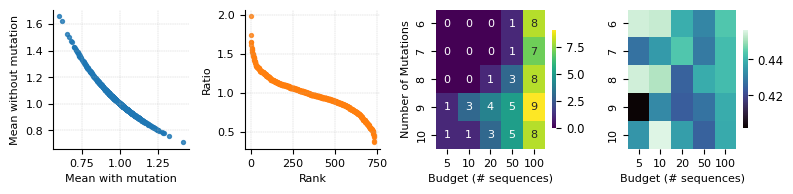

{3: array([ 13, 343, 729]),
 4: array([ 13, 343, 729, 350]),
 5: array([ 13, 343, 729, 350, 264]),
 6: array([ 13, 343, 729, 350, 264, 588]),
 7: array([ 13, 343, 729, 350, 264, 588, 523]),
 8: array([ 13, 343, 729, 350, 264, 588, 523, 574]),
 9: array([ 13, 343, 729, 350, 264, 588, 523, 574,  46]),
 10: array([ 13, 343, 729, 350, 264, 588, 523, 574,  46, 411])}

In [ ]:
 # Annotate heatmap axes: 
# Columns: Budget = [5, 10, 20, 50, 100]
# Rows: Number of mutations = [6, 7, 8, 9, 10]

dataset_path = DATASET_PATHS["gcn4"]
df = pd.read_csv(dataset_path)

# get one-hot encoding for relevant columns
relevant_columns = get_relevant_columns('gcn4', df)
ohe = get_one_hot_encoding(df, relevant_columns)
ohe_columns = ohe.columns
ohe = ohe.to_numpy().astype(int)
assert ohe.shape[1] == sum([len(pd.unique(df[C])) for C in relevant_columns])

activity_col = datasets_and_activity[dataset]["activity_col"]
activity = df[activity_col].to_numpy()

mean_with_mutation_per_column = []
mean_without_mutation_per_column = []
for i in range(ohe.shape[1]):
    mean_val_with_mutation = np.mean(activity[np.where(ohe[:, i] == 1)[0]])
    mean_val_without_mutation = np.mean(activity[np.where(ohe[:, i] == 0)[0]])
    mean_with_mutation_per_column.append(mean_val_with_mutation/mean_val_without_mutation)
    mean_without_mutation_per_column.append(mean_val_without_mutation/mean_val_with_mutation)

budget_labels = [5, 10, 20, 50, 100]
num_mutations_labels = [6, 7, 8, 9, 10]

gof_matrix = all_results["gcn4_esm2_t6_8M_UR50D"]["unique_gof_matrix"][3:,:]
activity_matrix = all_results["gcn4_esm2_t6_8M_UR50D"]["unique_median_activity_matrix"][3:,:]
activity_matrix = activity_matrix / max_dict["gcn4"]

fig, axes = plt.subplots(1, 4, figsize=(8, 2))

# First scatter plot: mean_with_mutation vs mean_without_mutation
axes[0].scatter(mean_with_mutation_per_column, mean_without_mutation_per_column, color='tab:blue', alpha=0.8, s=8)
axes[0].set_xlabel("Mean with mutation", fontsize=8)
axes[0].set_ylabel("Mean without mutation", fontsize=8)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.3, alpha=0.7)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='both', labelsize=8)
# No title

# Second scatter plot: cumulative distribution of ratios
sorted_ratio = -1 * np.sort(-np.array(mean_with_mutation_per_column)/np.array(mean_without_mutation_per_column))
axes[1].scatter(np.arange(1, len(sorted_ratio)+1), sorted_ratio, color='tab:orange', alpha=0.8, s=8)
axes[1].set_xlabel("Rank", fontsize=8)
axes[1].set_ylabel("Ratio", fontsize=8)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.3, alpha=0.7)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='both', labelsize=8)
# No title

# Third plot: Unique GOF matrix heatmap
sns.heatmap(
    gof_matrix,
    annot=True,
    cmap="viridis",
    ax=axes[2],
    xticklabels=budget_labels,
    yticklabels=num_mutations_labels,
    annot_kws={'fontsize': 8},
    cbar_kws={'shrink': 0.7},
    cbar=False
)
axes[2].set_xlabel("Budget (# sequences)", fontsize=8)
axes[2].set_ylabel("Number of Mutations", fontsize=8)
axes[2].tick_params(axis='both', labelsize=8)
# No title

# Fourth plot: Unique Median Activity Matrix heatmap
sns.heatmap(
    activity_matrix,
    annot=False,
    cmap="mako",
    ax=axes[3],
    xticklabels=budget_labels,
    yticklabels=num_mutations_labels,
    annot_kws={'fontsize': 8},
    cbar_kws={'shrink': 0.7},
    cbar=True
)
axes[3].set_xlabel("Budget (# sequences)", fontsize=8)
axes[3].set_ylabel("", fontsize=8)
axes[3].tick_params(axis='both', labelsize=8)
# No title

plt.tight_layout()
fig_out_dir = os.path.join("refined_figures", "figure_gof_activity_heatmaps")
os.makedirs(fig_out_dir, exist_ok=True)
svg_path = os.path.join(fig_out_dir, "joint_heatmaps_legend.svg")
fig.savefig(svg_path, format="svg")
plt.show()

all_results["gcn4_esm2_t6_8M_UR50D"]["unique_chosen_indices"]